In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
%matplotlib inline

In [3]:
# Read the dataset and take a quick look
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# Assign the predictor and response variables.
# Outcome is the response and all the other columns are the predictors
X = df.drop("Outcome", axis=1)
y = df['Outcome']

In [5]:
# Helper function to plot the impurity-based feature importances of the defined model
def plot_feature_importance(model1, model2):

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

  # Plot for Random Forest
  tree_importance_sorted_idx = np.argsort(model1.feature_importances_)
  tree_indices = np.arange(0, len(model1.feature_importances_)) + 0.5

  ax1.barh(tree_indices, 
           model1.feature_importances_[tree_importance_sorted_idx], 
           height=0.7, color='#B2D7D0')
  ax1.set_yticklabels(X.columns[tree_importance_sorted_idx], 
                        fontsize=12)
  ax1.set_yticks(tree_indices)
  ax1.set_ylim((0, len(model1.feature_importances_)))
  ax1.set_xlabel("Impurity Based Feature Importance", fontsize=16)
  #ax1.set_ylabel("Predictors", fontsize=16)

  # Plot for Bagging

  tree_importance_sorted_idx = np.argsort(model2.feature_importances_)
  tree_indices = np.arange(0, len(model2.feature_importances_)) + 0.5

  ax2.barh(tree_indices, model2.feature_importances_[tree_importance_sorted_idx], 
          height=0.7, color='#EFAEA4')
  ax2.set_yticklabels(X.columns[tree_importance_sorted_idx], fontsize=12)
  ax2.set_yticks(tree_indices)
  ax2.set_ylim((0, len(model2.feature_importances_)))
  ax2.set_xlabel("Impurity Based Feature Importance", fontsize=16)

  ax1.set_title("Random Forest", fontsize=18)
  ax2.set_title("Single Tree", fontsize=18)
  fig.tight_layout()
  plt.show()

In [6]:
# Helper function to plot the feature importance for the defined model
def plot_permute_importance(result1, result2):

    # Plot for random forest
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

    tree_importance_sorted_idx = np.argsort(result1.importances_mean)
    tree_indices = np.arange(0, len(result1.importances_mean)) +0.5

    ax1.barh(tree_indices, result1.importances_mean[tree_importance_sorted_idx], 
              height=0.7, color='#B2D7D0')
    ax1.set_yticklabels(X.columns[tree_importance_sorted_idx], fontsize=12)
    ax1.set_yticks(tree_indices)
    ax1.set_ylim((0, len(result1.importances_mean)))
    ax1.set_xlabel("Permutation Feature Importance", fontsize=16)
    #ax1.set_ylabel("Predictors", fontsize=16)

  # Plot for Bagging

    tree_importance_sorted_idx2 = np.argsort(result2.importances_mean)
    tree_indices2 = np.arange(0, len(result2.importances_mean)) +0.5

    ax2.barh(tree_indices2, result2.importances_mean[tree_importance_sorted_idx2], 
              height=0.7, color='#EFAEA4')
    ax2.set_yticklabels(X.columns[tree_importance_sorted_idx2], fontsize=12)
    ax2.set_yticks(tree_indices2)
    ax2.set_ylim((0, len(result2.importances_mean)))
    ax2.set_xlabel("Permutation Feature Importance", fontsize=16)

    ax1.set_title("Random Forest", fontsize=18)
    ax2.set_title("Single Tree", fontsize=18)
    fig.tight_layout()
    plt.show()

### RANDOM FOREST

In [7]:
# Set the parameters
max_depth = 20

# Define a Random Forest classifier with randon_state = 10
# Set the maximum depth to be max_depth and use 10 estimators

forest = RandomForestClassifier(max_depth=max_depth, random_state=10, n_estimators=10)

# Fit the model on the entire data
forest.fit(X, y);

# Using Permutation Importance to get the importance of features for the random forest model with random_state 42
result = __(__, X, y,
                    random_state=42)

0.7794270833333332

### SINGLE TREE

In [8]:
# Define a Decision Tree classifier with randon_state = 44
# Set the maximum depth to be max_depth

tree = DecisionTreeClassifier(max_depth=max_depth, random_state=44)

# Fit the model on the entire data
tree.fit(X, y);

DecisionTreeClassifier(max_depth=20, random_state=44)

In [9]:
# Using Permutation Importance to get the importance of features for the bagging model with random_state 42
tree_result = __(__, X, y,
                                random_state=42)

<ipython-input-1-82aa3d709d26>:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(X.columns[tree_importance_sorted_idx], fontsize=12)
<ipython-input-1-82aa3d709d26>:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_yticklabels(X.columns[tree_importance_sorted_idx2], fontsize=12)


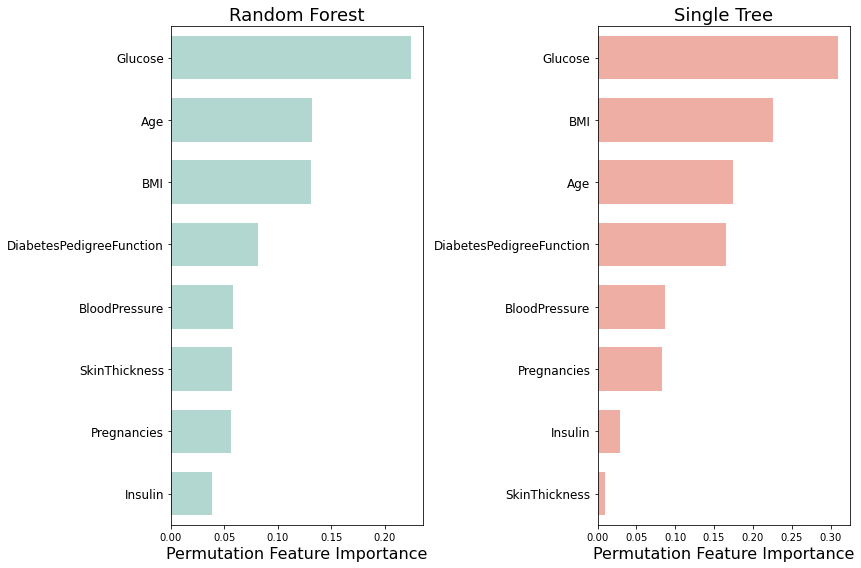

In [10]:
# Feature importance using permutation importance
plot_permute_importance(result,tree_result);

<ipython-input-1-38579503f454>:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(X.columns[tree_importance_sorted_idx],
<ipython-input-1-38579503f454>:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_yticklabels(X.columns[tree_importance_sorted_idx], fontsize=12)


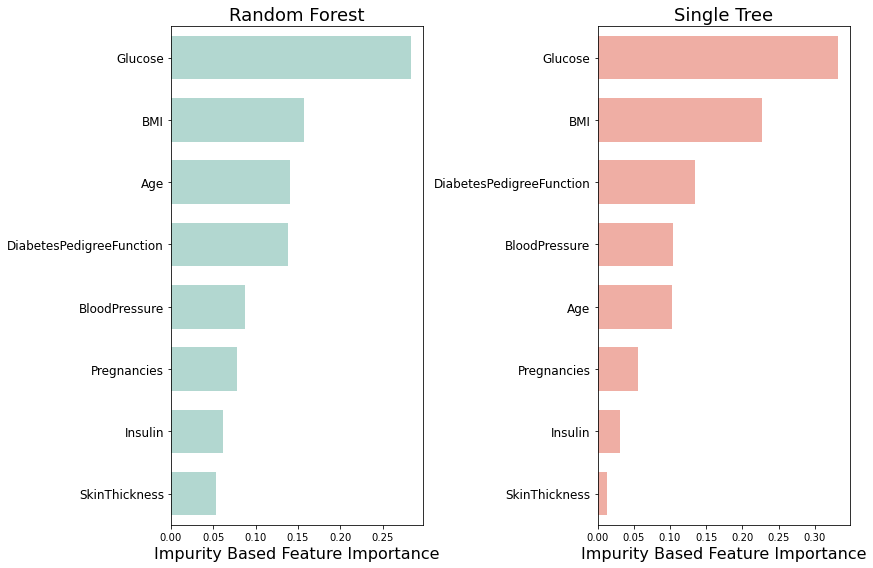

In [11]:
# Feature importance using feature importance
plot_feature_importance(forest,tree);